In [1]:
## TO RUN ON THE CLOUD 

## preprocessed the data before starting the slide
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [2]:
fo.list_datasets(
    
)

['FLPLAN',
 'UM_teste',
 'WPonly_1024ov224',
 'flplan200',
 'flplanpatches',
 'nc765',
 'nc765_T1024ov224',
 'nc765_T2048ov224',
 'tiles2048_merged',
 'tiles_merged',
 'tiles_merged_2048',
 'train_nc_wp_T1024ov224',
 'umflplan_T1024ov224',
 'umflplan_T2048ov224',
 'wp125',
 'wp125_T1024ov224',
 'wp125_T2048ov224',
 'wp_final_test']

In [9]:
wp_mix = fo.load_dataset("wp125")
wp_mix.count_values("parent_name")

{'FRIWEN_M8': 21,
 'FRIWEN_M19': 3,
 'FRIWEN_M12': 11,
 'UM_M5': 23,
 'GAM_M1': 12,
 'GAM_M2': 11,
 'GAM_M10': 4,
 'MANTASANDY_M5': 3,
 'FRIWEN_M53': 4,
 'UM_M6': 9,
 'UM_M2': 9,
 'UM_M1': 14,
 'FRIWEN_M11': 24,
 'UM_M3': 4}

In [18]:
wp_mix_um = wp_mix.match(
    ViewField("subregion").is_in("UM")
)
wp_mix_um.count("ground_truth.detections.label")

105

In [21]:
um_flplan = fo.load_dataset("FLPLAN")
um_flplan.count("ground_truth.detections.label")

86

In [14]:
from fiftyone import ViewField

wp_oo  = wp_mix.match(
    ViewField("subregion").is_in(["FRIWEN","GAM","MANTSANDY"])
)
wp_oo.count("ground_truth.detections.label")

154

In [10]:
for sample in wp_mix.iter_samples(progress=True):
    subregion = sample['parent_name'].split('_')[0]
    sample['subregion'] = subregion
    sample.save()

 100% |█████████████████| 152/152 [8.5s elapsed, 0s remaining, 18.5 samples/s]       


In [7]:

unq_filepath = dataset.values("source_image")
import pandas as pd 
len(pd.Series(unq_filepath).unique())

235

In [10]:
dataset = fo.load_dataset("nc765_T1024ov224")

In [11]:
session = fo.launch_app(dataset, auto=False, port=5151)


Could not connect session, trying again in 10 seconds

Session launched. Run `session.show()` to open the App in a cell output.


In [12]:
sss = session.selected
session.view = dataset[sss]

In [14]:
ss = session.selected
dataset[ss].values("filepath")

['/share/home/e2406743/dataset/tiles_all/nc765/positive/images/GH024196-60e7133bc685e_1513__tile_0_800_t1024_o224.jpg',
 '/share/home/e2406743/dataset/tiles_all/nc765/positive/images/GH024197-60e713a81ab1d_1451__tile_496_1680_t1024_o224.jpg',
 '/share/home/e2406743/dataset/tiles_all/nc765/positive/images/GH024222-619e3ad527b0b_216__tile_0_800_t1024_o224.jpg',
 '/share/home/e2406743/dataset/tiles_all/nc765/positive/images/GH034196-60e7f35f21cd1_790__tile_496_0_t1024_o224.jpg',
 '/share/home/e2406743/dataset/tiles_all/nc765/positive/images/GH034200-60f5479af38d8_1158__tile_496_1680_t1024_o224.jpg',
 '/share/home/e2406743/dataset/tiles_all/nc765/positive/images/GH034207-611a6e787d0af_1997__tile_496_1600_t1024_o224.jpg',
 '/share/home/e2406743/dataset/tiles_all/nc765/positive/images/GH044209-6110f222b5b35_553__tile_0_800_t1024_o224.jpg',
 '/share/home/e2406743/dataset/tiles_all/nc765/positive/images/GH054222-619e46bead185_104__tile_496_800_t1024_o224.jpg',
 '/share/home/e2406743/dataset/ti

In [9]:
session.close()

In [6]:
test_view = dataset.match_tags("test_3")

unq_filepath = test_view.values("source_image")
import pandas as pd 
len(pd.Series(unq_filepath).unique())

51

In [7]:
list(dataset.count_values("tags").keys())

['test_0',
 'val_0',
 'test_3',
 'test_2',
 'train_3',
 'train_1',
 'train_0',
 'test_1',
 'train_2']

In [ ]:
import pandas as pd

pd.Series(dataset.values("source_image")).unique()

In [127]:
from fiftyone import ViewField
dataset.match(
    ViewField("type_label").contains_str("positive")
).count_values("flight_unique")

{'GAM_M1': 28,
 'UM_M48': 16,
 'UM_M46': 27,
 'UM_M15': 16,
 'UM_M2': 16,
 'UM_M6': 18,
 'UM_M40': 34,
 'GAM_M10': 8,
 'MANTASANDY_M5': 4,
 'FRIWEN_M53': 10,
 'FRIWEN_M12': 23,
 'FRIWEN_M19': 3,
 'FRIWEN_M8': 54,
 'UM_M33': 15,
 'FRIWEN_M11': 49,
 'GAM_M2': 23,
 'UM_M4': 3,
 'UM_M3': 6,
 'UM_M35': 13,
 'UM_M5': 67,
 'UM_M1': 26,
 'UM_M13': 17}

In [ ]:
## create an identifier for each flight mission 
import re 
for sample in dataset.iter_samples(progress=True):
    name_par = sample['parent_name']
    m = re.search(r"UM_M(\d+)", name_par)
    end = f"UM_M{m.group(1)}" if m else name_par
    sample['flight_unique'] = end
    sample.save()

## add a subregion 
for sample in dataset.iter_samples(progress=True):
    subregion = sample['flight_unique']
    sample['subregion'] = subregion.split('_')[0]
    sample.save()

## save um as view 
um_view = dataset.match(
    ViewField("subregion").contains_str("UM")
)
dataset.save_view("um_view",um_view)

  14% |██/--------------|  68/476 [103.8ms elapsed, 623.0ms remaining, 654.9 samples/s] 

 100% |█████████████████| 476/476 [619.5ms elapsed, 0s remaining, 768.4 samples/s]      


In [138]:
um_view.count_values("flight_unique")

{'UM_M15': 16,
 'UM_M33': 15,
 'UM_M48': 16,
 'UM_M35': 13,
 'UM_M46': 27,
 'UM_M4': 3,
 'UM_M40': 34,
 'UM_M13': 17,
 'UM_M1': 26,
 'UM_M2': 16,
 'UM_M5': 67,
 'UM_M3': 6,
 'UM_M6': 18}

In [139]:
from collections import defaultdict

flights = um_view.count_values("flight_unique")

n_groups = 3

# Initialize groups
groups = [[] for _ in range(n_groups)]
totals = [0] * n_groups

# Sort flights by size (largest first)
sorted_flights = sorted(flights.items(), key=lambda x: x[1], reverse=True)

# Greedily assign each flight
for flight, n_images in sorted_flights:
    idx = totals.index(min(totals))
    groups[idx].append(flight)
    totals[idx] += n_images

# Print results
for i, (group, total) in enumerate(zip(groups, totals), 1):
    print(f"Group {i} ({total} images):")
    print(group)
    print()

Group 1 (96 images):
['UM_M5', 'UM_M48', 'UM_M35']

Group 2 (88 images):
['UM_M40', 'UM_M6', 'UM_M13', 'UM_M2', 'UM_M4']

Group 3 (90 images):
['UM_M46', 'UM_M1', 'UM_M15', 'UM_M33', 'UM_M3']



In [145]:
um_view.count_values("flight_unique")

{'UM_M15': 16,
 'UM_M33': 15,
 'UM_M48': 16,
 'UM_M35': 13,
 'UM_M46': 27,
 'UM_M4': 3,
 'UM_M40': 34,
 'UM_M13': 17,
 'UM_M1': 26,
 'UM_M3': 6,
 'UM_M5': 67,
 'UM_M2': 16,
 'UM_M6': 18}

In [151]:
## prepare the test at  k-fold split of 3 
seed1 = ['UM_M5', 'UM_M48', 'UM_M35']
seed2 = ['UM_M40', 'UM_M6', 'UM_M13', 'UM_M2', 'UM_M4']
seed3 = ['UM_M46', 'UM_M1', 'UM_M15', 'UM_M33', 'UM_M3']

um_view.match(
    ViewField("flight_unique").is_in(seed1)
).tag_samples("test_1")

um_view.match(
    ViewField("flight_unique").is_in(seed2)
).tag_samples("test_2")

um_view.match(
    ViewField("flight_unique").is_in(seed3)
).tag_samples("test_3")

In [154]:
dataset.match_tags("test_1",bool=False).tag_samples("train_1")
dataset.match_tags("test_2",bool=False).tag_samples("train_2")
dataset.match_tags("test_3",bool=False).tag_samples("train_3")

In [132]:
sss = dataset.match(
    ViewField("subregion").contains_str("UM")
).values("source_image")
len(pd.Series(sss).unique())

142

In [133]:
dataset.match(
    ViewField("subregion").contains_str("UM")
).count_values("flight_unique")

{'UM_M15': 16,
 'UM_M33': 15,
 'UM_M48': 16,
 'UM_M35': 13,
 'UM_M46': 27,
 'UM_M4': 3,
 'UM_M40': 34,
 'UM_M13': 17,
 'UM_M1': 26,
 'UM_M3': 6,
 'UM_M5': 67,
 'UM_M2': 16,
 'UM_M6': 18}

# Extracting embeddings

In [155]:
import fiftyone.zoo as foz
import fiftyone.brain as fob
from fiftyone import ViewField as F
import fiftyone.operators as foo
from fiftyone.utils.huggingface import load_from_hub
import cv2
import numpy as np
import fiftyone.brain as fob
import fiftyone.utils.transformers as fout
import numpy as np 

In [156]:
from transformers import AutoImageProcessor, AutoModel

MODEL_ID  = "facebook/dinov3-vitl16-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model     = AutoModel.from_pretrained(MODEL_ID)



Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

In [157]:
# Change resize target from 224x224 to e.g. 448x448 or 512x512
processor.size = {"height": 1024, "width": 1024}
print(processor.size)  

{'height': 1024, 'width': 1024}


In [158]:
dataset.count_values("tags")

{'test_0': 59,
 'val_0': 24,
 'test_3': 90,
 'train_2': 388,
 'train_1': 380,
 'train_3': 386,
 'test_2': 88,
 'train_0': 393,
 'test_1': 96}

In [ ]:
train_view = dataset.match_tags("train_0")

In [10]:
## Here I compute the embedding for the full image 
embeddings = train_view.compute_embeddings(
    model,
    embeddings_field=None,
    num_workers =2,
    batch_size=4,
    progress=True,  
)

 100% |█████████████████| 393/393 [5.9s elapsed, 0s remaining, 65.8 samples/s]       


In [11]:
from pathlib import Path
import os
import numpy as np 
from fiftyone import ViewField

In [12]:
sample_ids_list = np.array(train_view.values("id"))
stem_list = np.array([Path(f).stem for f in train_view.values("filepath")])


## save 
folder_emb = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3"
out_file = "train_positive_TESTE_1024_embeddings.npz"

np.savez_compressed(
    os.path.join(folder_emb,out_file),
    embeddings = embeddings,
    sample_ids = sample_ids_list,
    stem_filepath = stem_list
)

## Active Learning Selection 

In [26]:
import sys
%load_ext autoreload
%autoreload 2

In [51]:
from src.aclr_selection import (
    active_learning_centroid, aclr_centroid_uniqueness,
    aclr_ball_radius, random_baseline)

from src.active_learning import compute_clustering

In [50]:
import importlib
import src.aclr_selection
import src.active_learning

importlib.reload(src.aclr_selection)
importlib.reload(src.active_learning)

<module 'src.active_learning' from '/share/castor/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/src/active_learning.py'>

In [15]:
# compute clustering at the train view 
cluster_labels, embeddings_norm, sample_ids = compute_clustering(
    train_view, 
    embeddings=embeddings, 
    sample_ids=sample_ids_list, 
    n_clusters=12,
    cluster_field = "train_cluster_label",
    save=True)

  Using pre-loaded embeddings array: (393, 1024) (393 sample_ids).
  Resolved 393 embeddings, dim=1024
  KMeans: n_clusters=12  n_init=10  seed=42
  KMeans done: min_size=22  mean_size=32.8  max_size=51
  Empty clusters: 0 / 12
  Writing field 'train_cluster_label' to dataset ...
 100% |█████████████████| 393/393 [368.5ms elapsed, 0s remaining, 1.1K samples/s]      
bum! Cluster labels saved to 'train_cluster_label' (as strings -- categorical, not numeric -- for proper dropdown/discrete coloring in the FiftyOne App).


In [18]:
len(sample_ids)

393

In [52]:
## Compute the active learning for different methods 
parts = [0.05, 0.10, 0.25, 0.40, 0.5, 0.75]

# centroid 
active_learning_centroid(train_view, 
                         cluster_labels, 
                         embeddings_norm, 
                         sample_ids, 
                         parts, 
                         "json_ids_training/centroid.json")


# centroid / uniqueness
aclr_centroid_uniqueness(train_view, 
                         cluster_labels, 
                         embeddings_norm, 
                         sample_ids, 
                         parts, 
                         "json_ids_training/cent_uniq.json", 
                         rho=0.50
                         )

# ball radius 
aclr_ball_radius(train_view, 
                 cluster_labels, 
                 embeddings_norm, 
                 sample_ids, 
                 parts, 
                 "json_ids_training/ball.json", 
                 ball_radius=0.5
                 )

## random baseline 
random_baseline(train_view, 
                sample_ids, 
                parts, 
                "json_ids_training/random.json"
                )

  [centroid] N=393  clusters=12  partitions=[0.05, 0.1, 0.25, 0.4, 0.5, 0.75]
  budget p5: target=20  allocated=20
  budget p10: target=39  allocated=39
  budget p25: target=98  allocated=98
  budget p40: target=157  allocated=157
  budget p50: target=196  allocated=196
  budget p75: target=295  allocated=295
  partition p5: selected 20 (target 20)
  partition p10: selected 39 (target 39)
  partition p25: selected 98 (target 98)
  partition p40: selected 157 (target 157)
  partition p50: selected 196 (target 196)
  partition p75: selected 295 (target 295)
  p5: 20 images resolved.
  p10: 39 images resolved.
  p25: 98 images resolved.


  p40: 157 images resolved.
  p50: 196 images resolved.
  p75: 295 images resolved.
OK   wrote json_ids_training/centroid.json
  [centroid_uniqueness] N=393  clusters=12  rho=0.5  k=5
    uniqueness cluster   0: n=  35  k_eff=5  mean=0.4611
    uniqueness cluster   1: n=  34  k_eff=5  mean=0.2491
    uniqueness cluster   2: n=  22  k_eff=5  mean=0.2386
    uniqueness cluster   3: n=  37  k_eff=5  mean=0.5101
    uniqueness cluster   4: n=  40  k_eff=5  mean=0.2995
    uniqueness cluster   5: n=  37  k_eff=5  mean=0.4105
    uniqueness cluster   6: n=  25  k_eff=5  mean=0.1892
    uniqueness cluster   7: n=  51  k_eff=5  mean=0.2787
    uniqueness cluster   8: n=  23  k_eff=5  mean=0.4641
    uniqueness cluster   9: n=  30  k_eff=5  mean=0.3449
    uniqueness cluster  10: n=  36  k_eff=5  mean=0.4090
    uniqueness cluster  11: n=  23  k_eff=5  mean=0.2872
  budget p5: target=20  allocated=20
  budget p10: target=39  allocated=39
  budget p25: target=98  allocated=98
  budget p40: targe

{'0': {'train': {'p5': {'random': {'images': ['/share/home/e2406743/dataset/tiles_all/wp125/positive/images/MAN_P4_GAM_M2_F2_GSP_DJI_0324-65733686d0e93_35__tile_800_1600_t1024_o224.jpg',
      '/share/home/e2406743/dataset/tiles_all/wp125/positive/images/MAN_P4_FRIWEN_M12_F3_GSP_DJI_0029-66acda8b6f3f5_1__tile_1136_1600_t1024_o224.jpg',
      '/share/home/e2406743/dataset/tiles_all/wp125/positive/images/MAN_P4_GAM_M1_F2_GSP_DJI_0309-64ec46505487e_30__tile_1136_1600_t1024_o224.jpg',
      '/share/home/e2406743/dataset/tiles_all/umflplan/positive/images/FPLAN_M4_UM_M13_F1_2025_P_4-6973e124ed55b_47__tile_0_2400_t1024_o224.jpg',
      '/share/home/e2406743/dataset/tiles_all/umflplan/positive/images/FPLAN_P4P_UM_M48_F1_2025_GSP-697e1055e6795_773__tile_2624_0_t1024_o224.jpg',
      '/share/home/e2406743/dataset/tiles_all/umflplan/positive/images/FPLAN_M4_UM_M4_F1_2025_P-69723dd2b68b6_208__tile_1600_2400_t1024_o224.jpg',
      '/share/home/e2406743/dataset/tiles_all/wp125/positive/images/MAN_P

# Visualize the active learning selection 

In [36]:
from src.viz_aclr_tsne import compute_tsne, visualize_partition_from_json



In [82]:
import src.viz_aclr_tsne

reload(src.viz_aclr_tsne)

<module 'src.viz_aclr_tsne' from '/share/castor/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/src/viz_aclr_tsne.py'>

In [ ]:
coords = compute_tsne(embeddings_norm, 
                        perplexity = 99,
                        seed=42)   # compute ONCE, reuse for every partition

  centroid.json [p25] centroid: 98 rows
  cent_uniq.json [p25] centroid_uniqueness: 98 rows
  ball.json [p25] ball_radius: 98 rows


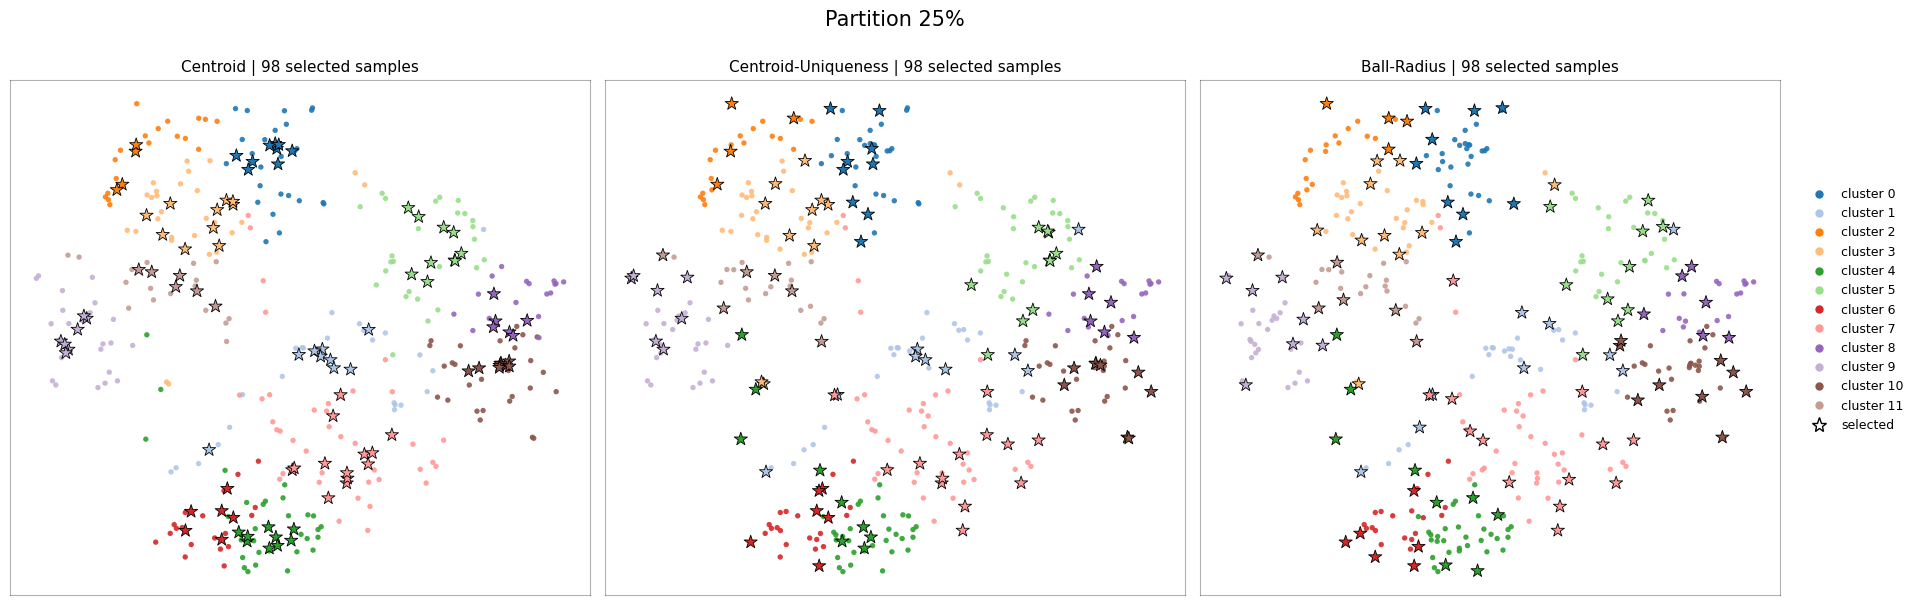

In [83]:


fig, axes, coords = visualize_partition_from_json(
    embeddings_norm, cluster_labels, sample_ids, train_view,
    json_paths={
        "Centroid":            "json_ids_training/centroid.json",
        "Centroid-Uniqueness": "json_ids_training/cent_uniq.json",
        "Ball-Radius":  "json_ids_training/ball.json",
    },
    partition=0.25,
    coords=coords,
    bg_size=15, 
    bg_alpha=0.90,
    sel_size=100, 
    sel_marker="*",
    sel_edgecolor="black", 
    sel_edgewidth=0.6,
    #save_path="tsne_p50.png",
)

  centroid.json [p10] centroid: 39 rows
  cent_uniq.json [p10] centroid_uniqueness: 39 rows
  ball.json [p10] ball_radius: 39 rows


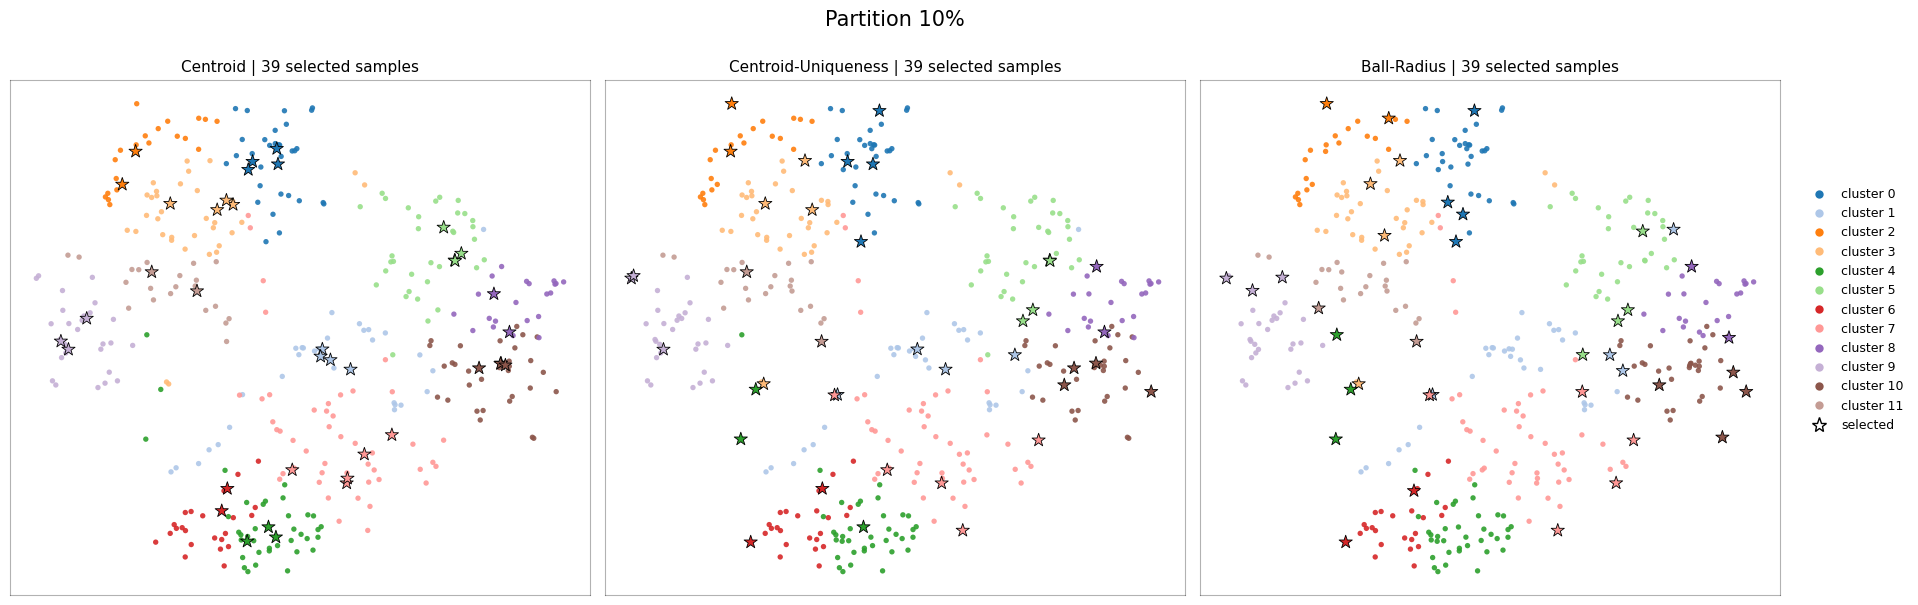

In [84]:


fig, axes, coords = visualize_partition_from_json(
    embeddings_norm, cluster_labels, sample_ids, train_view,
    json_paths={
        "Centroid":            "json_ids_training/centroid.json",
        "Centroid-Uniqueness": "json_ids_training/cent_uniq.json",
        "Ball-Radius":  "json_ids_training/ball.json",
    },
    partition=0.10,
    coords=coords,
    bg_size=15, 
    bg_alpha=0.90,
    sel_size=100, 
    sel_marker="*",
    sel_edgecolor="black", 
    sel_edgewidth=0.6,
    #save_path="tsne_p50.png",
)

  centroid.json [p50] centroid: 196 rows
  cent_uniq.json [p50] centroid_uniqueness: 196 rows
  ball.json [p50] ball_radius: 196 rows


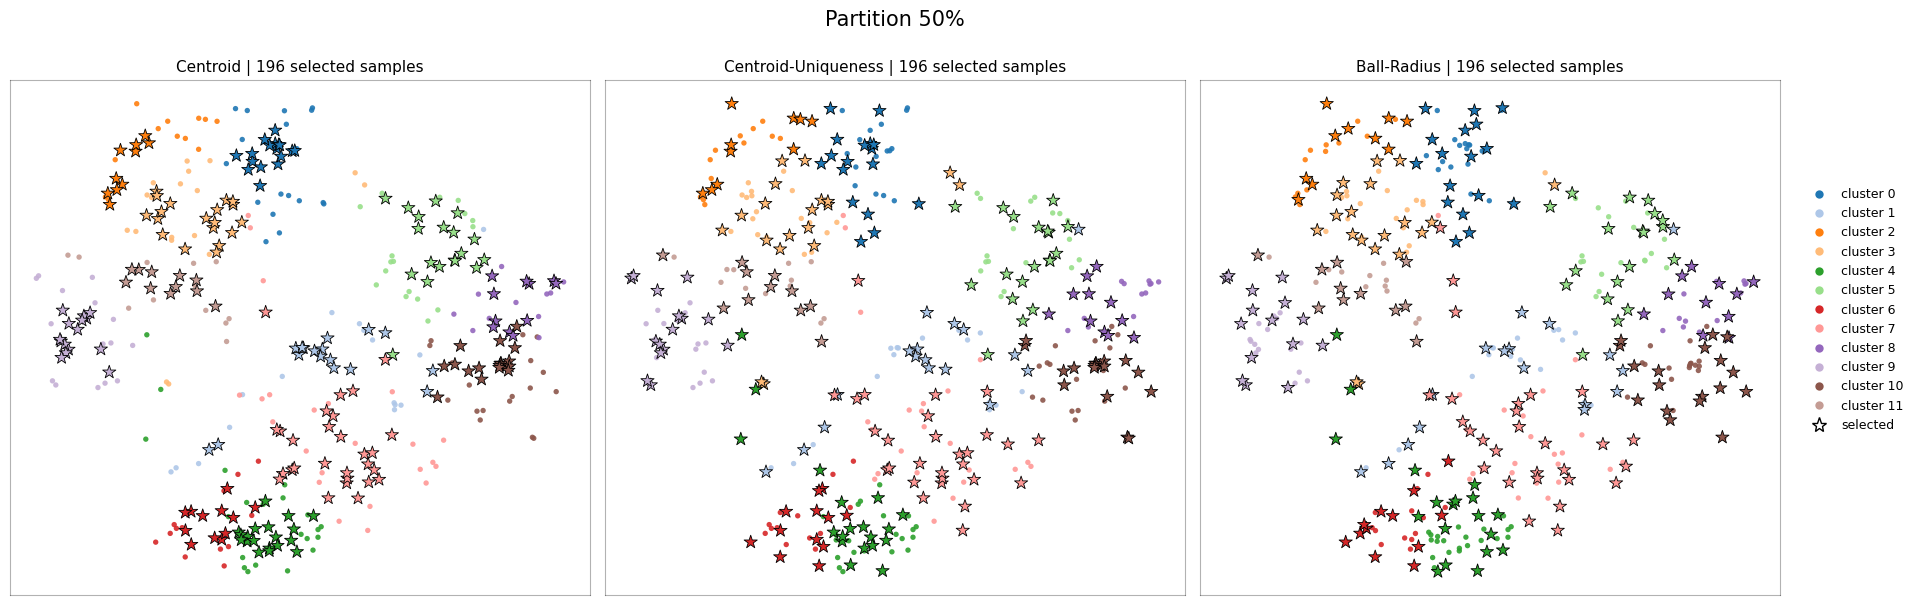

In [86]:


fig, axes, coords = visualize_partition_from_json(
    embeddings_norm, cluster_labels, sample_ids, train_view,
    json_paths={
        "Centroid":            "json_ids_training/centroid.json",
        "Centroid-Uniqueness": "json_ids_training/cent_uniq.json",
        "Ball-Radius":  "json_ids_training/ball.json",
    },
    partition=0.50,
    coords=coords,
    bg_size=15, 
    bg_alpha=0.90,
    sel_size=100, 
    sel_marker="*",
    sel_edgecolor="black", 
    sel_edgewidth=0.6,
    #save_path="tsne_p50.png",
)

In [55]:
session = fo.launch_app(dataset,auto=False,port=5151)

Session launched. Run `session.show()` to open the App in a cell output.


In [56]:
train_view.count_values('parent_name')

{'GAM_M1': 28,
 'FPLAN_M4_UM_M13_F1_2025_P_4-6973e124ed55b_26_03_09': 11,
 'UM_M2': 16,
 'FPLAN_P4P_UM_M15_F1_2025_GSP-697622d8e60f0_26_03_09': 13,
 'UM_M6': 18,
 'FRIWEN_M53': 10,
 'FPLAN_M4_UM_M40_F1_2025_P_2-699839d1afc67_26_03_10': 8,
 'FPLAN_P4P_UM_M48_F1_2025_GSP-697e1055e6795_26_03_09': 15,
 'FRIWEN_M12': 21,
 'FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_26_03_10': 8,
 'FPLAN_M4_UM_M40_F1_2025_P_3-69983e8785b05_26_03_10': 22,
 'FPLAN_M4_UM_M40_F1_2025_P_1-69983452bef98_26_03_10': 1,
 'FRIWEN_M11': 49,
 'FRIWEN_M8': 52,
 'GAM_M2': 23,
 'UM_M5': 67,
 'FPLAN_M4_UM_M4_F1_2025_P-69723dd2b68b6_26_03_09': 3,
 'UM_M1': 26,
 'FPLAN_M4_UM_M13_F1_2025_P_1-6973989e86e75_26_03_09': 2}

In [59]:
import pandas as pd
pd.Series(train_view.values('source_image')).unique()

<ArrowStringArray>
['/share/home/e2406743/dataset/new_dataset/UM_DUGONG_2025/FPLAN_M4_UM_M13_F1_2025_P_1-6973989e86e75_26_03_09/images/FPLAN_M4_UM_M13_F1_2025_P_1-6973989e86e75_363.jpeg',
 '/share/home/e2406743/dataset/new_dataset/UM_DUGONG_2025/FPLAN_M4_UM_M13_F1_2025_P_4-6973e124ed55b_26_03_09/images/FPLAN_M4_UM_M13_F1_2025_P_4-6973e124ed55b_163.jpeg',
  '/share/home/e2406743/dataset/new_dataset/UM_DUGONG_2025/FPLAN_M4_UM_M13_F1_2025_P_4-6973e124ed55b_26_03_09/images/FPLAN_M4_UM_M13_F1_2025_P_4-6973e124ed55b_47.jpeg',
  '/share/home/e2406743/dataset/new_dataset/UM_DUGONG_2025/FPLAN_M4_UM_M13_F1_2025_P_4-6973e124ed55b_26_03_09/images/FPLAN_M4_UM_M13_F1_2025_P_4-6973e124ed55b_48.jpeg',
  '/share/home/e2406743/dataset/new_dataset/UM_DUGONG_2025/FPLAN_M4_UM_M13_F1_2025_P_4-6973e124ed55b_26_03_09/images/FPLAN_M4_UM_M13_F1_2025_P_4-6973e124ed55b_61.jpeg',
  '/share/home/e2406743/dataset/new_dataset/UM_DUGONG_2025/FPLAN_M4_UM_M13_F1_2025_P_4-6973e124ed55b_26_03_09/images/FPLAN_M4_UM_M13_F1_

In [60]:
session.view = train_view

In [61]:
train_view.count_values("train_cluster_label")

{8.0: 23,
 5.0: 37,
 7.0: 51,
 0.0: 35,
 4.0: 40,
 1.0: 34,
 10.0: 36,
 6.0: 25,
 3.0: 37,
 11.0: 23,
 2.0: 22,
 9.0: 30}

### Plot the clustering 

In [100]:
personal_view_list = session.selected

In [101]:
len(personal_view_list)

62

In [103]:
import src.plots_helper

reload(src.plots_helper)

<module 'src.plots_helper' from '/share/castor/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/src/plots_helper.py'>

In [90]:
from src.plots_helper import plot_clusters_full_images

In [104]:
view_plot = train_view[personal_view_list]

In [ ]:
plot_clusters_full_images(
    view_plot,
    num_img_per_row=5,
    field_cluster = "train_cluster_label",
    field_image_name="region"
)

In [106]:
dataset.count_values("tags")

{'test_0': 59, 'train_0': 393, 'val_0': 24}

## full pipeline

In [ ]:
import os

base_path = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/json_ids_training"
list_train_l = ["train_1","train_2","train_3"]
folders = ["seed1","seed2","seed3"]

for i,train_seed in enumerate(list_train_l):
    print(f"Running seed: {train_seed}")
    os.makedirs(os.path.join(base_path,folders[i]),exist_ok=True)

    # filter the view 
    train_view = dataset.match_tags(train_seed)

    ## Here I compute the embedding for the full image 
    embeddings = train_view.compute_embeddings(
        model,
        embeddings_field=None,
        num_workers =2,
        batch_size=4,
        progress=True,  
    )

    sample_ids_list = np.array(train_view.values("id"))
    stem_list = np.array([Path(f).stem for f in train_view.values("filepath")])

    # compute the clustering
    # compute clustering at the train view 
    name_cluster = f"cluster_{train_seed}"
    cluster_labels, embeddings_norm, sample_ids = compute_clustering(
        train_view, 
        embeddings=embeddings, 
        sample_ids=sample_ids_list, 
        n_clusters=11,
        cluster_field = name_cluster,
        save=True)

    ## Compute the active learning for different methods 
    parts = [0.05, 0.10, 0.25, 0.40, 0.5, 0.75]

    # centroid 
    name_centroid= f"{train_seed}_centroid.json"
    active_learning_centroid(train_view, 
                            cluster_labels, 
                            embeddings_norm, 
                            sample_ids, 
                            parts, 
                            os.path.join(base_path,folders[i],name_centroid)
                            )


    # centroid / uniqueness
    name_uniq = f"{train_seed}_centroid_uniqueness.json"
    aclr_centroid_uniqueness(train_view, 
                            cluster_labels, 
                            embeddings_norm, 
                            sample_ids, 
                            partitions = parts, 
                            output_json = os.path.join(base_path,folders[i],name_uniq), 
                            rho=0.60
                            )

    # ball radius 
    name_ball = f"{train_seed}_ball.json"
    aclr_ball_radius(train_view, 
                    cluster_labels, 
                    embeddings_norm, 
                    sample_ids, 
                    parts, 
                    os.path.join(base_path,folders[i],name_ball), 
                    ball_radius=0.5
                    )

    ## random baseline 
    name_random = f"{train_seed}_random.json"
    random_baseline(train_view, 
                    sample_ids, 
                    parts, 
                    os.path.join(base_path,folders[i],name_random)
                    )


Could not connect session, trying again in 10 seconds

Running seed: train_1
 100% |█████████████████| 380/380 [4.5s elapsed, 0s remaining, 77.7 samples/s]       
  Using pre-loaded embeddings array: (380, 1024) (380 sample_ids).
  Resolved 380 embeddings, dim=1024
  KMeans: n_clusters=11  n_init=10  seed=42
  KMeans done: min_size=17  mean_size=34.5  max_size=46
  Empty clusters: 0 / 11
  Writing field 'cluster_train_1' to dataset ...
 100% |█████████████████| 380/380 [327.3ms elapsed, 0s remaining, 1.2K samples/s]      
bum! Cluster labels saved to 'cluster_train_1' (as strings -- categorical, not numeric -- for proper dropdown/discrete coloring in the FiftyOne App).
  [centroid] N=380  clusters=11  partitions=[0.05, 0.1, 0.25, 0.4, 0.5, 0.75]
  budget p5: target=19  allocated=19
  budget p10: target=38  allocated=38
  budget p25: target=95  allocated=95
  budget p40: target=152  allocated=152
  budget p50: target=190  allocated=190
  budget p75: target=285  allocated=285
  partitio


Could not connect session, trying again in 10 seconds



In [165]:
session.close


Could not connect session, trying again in 10 seconds



<bound method Session.close of Dataset:          wp_final_test
Media type:       image
Num samples:      393
Selected samples: 62
Selected labels:  0
Session URL:      http://localhost:5151/
View stages:
    1. MatchTags(tags=['train_0'], bool=True, all=False)>